In [51]:
import mplsoccer as mpl
import json
import numpy as np
import matplotlib.pyplot as plt

In [121]:
# Loading 2018 and 2022 world cup final
path2018 = "data/2018.json"
path2022 = "data/2022.json"

with open(path2018, 'r') as f:
    wc2018 = json.load(f)

test2018 = wc2018[4]
print(test2018.items())

dict_items([('id', '6d7450f7-2590-4b04-a2ae-9ed11602e342'), ('index', 5), ('period', 1), ('timestamp', '00:00:00.400'), ('minute', 0), ('second', 0), ('type', {'id': 30, 'name': 'Pass'}), ('possession', 2), ('possession_team', {'id': 785, 'name': 'Croatia'}), ('play_pattern', {'id': 9, 'name': 'From Kick Off'}), ('team', {'id': 785, 'name': 'Croatia'}), ('player', {'id': 5472, 'name': 'Mario MandÅ¾ukiÄ‡'}), ('position', {'id': 23, 'name': 'Center Forward'}), ('location', [61.0, 41.0]), ('duration', 1.159), ('related_events', ['3e17cab8-367e-47bb-b942-1d7a0b6f8ae5']), ('pass', {'recipient': {'id': 5469, 'name': 'Marcelo BrozoviÄ‡'}, 'length': 11.045361, 'angle': 3.050933, 'height': {'id': 1, 'name': 'Ground Pass'}, 'end_location': [50.0, 42.0], 'type': {'id': 65, 'name': 'Kick Off'}, 'body_part': {'id': 40, 'name': 'Right Foot'}})])


In [79]:
print("Starting Lineup for France - " + str(test2018["tactics"]["formation"]))
lineups = test2018["tactics"]["lineup"]
for i in lineups:
    print(i["position"]["name"] + ": " + i["player"]["name"] + ", " + str(i["player"]["id"]))

Starting Lineup for France - 442
Goalkeeper: Hugo Lloris, 3099
Right Back: Benjamin Pavard, 5476
Right Center Back: RaphaÃ«l Varane, 5485
Left Center Back: Samuel Yves Umtiti, 5492
Left Back: Lucas HernÃ¡ndez Pi, 5484
Right Defensive Midfield: Paul Pogba, 20004
Left Defensive Midfield: N''Golo KantÃ©, 3961
Right Midfield: Kylian MbappÃ© Lottin, 3009
Left Midfield: Blaise Matuidi, 4375
Right Center Forward: Antoine Griezmann, 5487
Left Center Forward: Olivier Giroud, 3604


In [80]:
print("Starting Lineup for Croatia - " + str(wc2018[1]["tactics"]["formation"]))
croatiaLineup = wc2018[1]["tactics"]["lineup"]
for i in croatiaLineup:
    print(i["position"]["name"] + ": " + i["player"]["name"] + ", " + str(i["player"]["id"]))

Starting Lineup for Croatia - 433
Goalkeeper: Danijel SubaÅ¡iÄ‡, 3444
Right Back: Å ime Vrsaljko, 5461
Right Center Back: Dejan Lovren, 3471
Left Center Back: Domagoj Vida, 5468
Left Back: Ivan StriniÄ‡, 5457
Center Defensive Midfield: Marcelo BrozoviÄ‡, 5469
Right Center Midfield: Luka ModriÄ‡, 5463
Left Center Midfield: Ivan RakitiÄ‡, 5470
Right Wing: Ante RebiÄ‡, 5465
Left Wing: Ivan PeriÅ¡iÄ‡, 5474
Center Forward: Mario MandÅ¾ukiÄ‡, 5472


In [137]:
passes = []
for event in wc2018:
    if event["type"]["name"] == "Pass" and event["player"]["id"] == 3009:
        passes.append(event)
        
print(passes[0])

{'id': '7963596f-b4fa-47fb-af93-391908841206', 'index': 139, 'period': 1, 'timestamp': '00:02:42.747', 'minute': 2, 'second': 42, 'type': {'id': 30, 'name': 'Pass'}, 'possession': 8, 'possession_team': {'id': 771, 'name': 'France'}, 'play_pattern': {'id': 4, 'name': 'From Throw In'}, 'team': {'id': 771, 'name': 'France'}, 'player': {'id': 3009, 'name': 'Kylian MbappÃ© Lottin'}, 'position': {'id': 12, 'name': 'Right Midfield'}, 'location': [74.0, 79.0], 'duration': 2.28, 'related_events': ['1e9da195-e897-4279-a9c4-b7fa654fec1a', 'ceaa5d40-13cb-48da-aa8e-ecfd7072ee7c'], 'pass': {'recipient': {'id': 5476, 'name': 'Benjamin Pavard'}, 'length': 12.649111, 'angle': -2.819842, 'height': {'id': 3, 'name': 'High Pass'}, 'end_location': [62.0, 75.0], 'type': {'id': 67, 'name': 'Throw-in'}, 'outcome': {'id': 9, 'name': 'Incomplete'}}}


In [138]:
pass_coord = list(map(lambda event: event["location"], passes))
receive_coord = list(map(lambda event: event["pass"]["end_location"], passes))

In [139]:
print(pass_coord[0], receive_coord[0])

[74.0, 79.0] [62.0, 75.0]


In [165]:
x1, y1 = np.array(pass_coord).T
x2, y2 = np.array(receive_coord).T

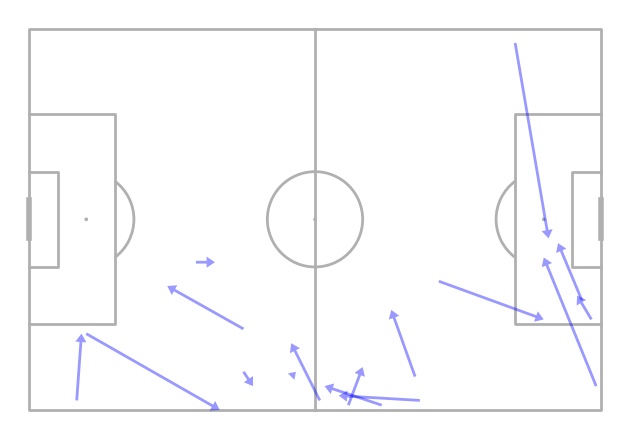

In [166]:
pitch = mpl.Pitch()
fig, ax = pitch.draw()

p = pitch.arrows(x1, y1, x2, y2, alpha=0.4, color="blue",
                 headaxislength=3, headlength=3, headwidth=4, width=2, ax=ax)

Attempting with pandas

In [167]:
import pandas as pd

df2018 = pd.read_json(path2018)

In [168]:
df2018.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,dribble,foul_committed,foul_won,clearance,ball_recovery,injury_stoppage,shot,goalkeeper,block,substitution
0,4a44199a-3111-4e28-b567-9c1393e68dff,1,1,2025-12-22 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2137ed27-042c-4d73-877c-75d04406617c,2,1,2025-12-22 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,531c8cbd-7a3e-4e46-91c1-549a98c27bcb,3,1,2025-12-22 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9b9060d4-13a5-4a44-aafa-2221ed10a8bc,4,1,2025-12-22 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 771, 'name': 'France'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6d7450f7-2590-4b04-a2ae-9ed11602e342,5,1,2025-12-22 00:00:00.400,0,0,"{'id': 30, 'name': 'Pass'}",2,"{'id': 785, 'name': 'Croatia'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [170]:
df2018.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'under_pressure', 'ball_receipt', 'duel', 'counterpress',
       'interception', 'dribble', 'foul_committed', 'foul_won', 'clearance',
       'ball_recovery', 'injury_stoppage', 'shot', 'goalkeeper', 'block',
       'substitution'],
      dtype='object')

In [175]:
df2018.iloc[11]

id                              a29c5a6c-6b85-409e-a43b-03f2d6bd3bf2
index                                                             12
period                                                             1
timestamp                                 2025-12-22 00:00:03.947000
minute                                                             0
second                                                             3
type                                      {'id': 30, 'name': 'Pass'}
possession                                                         2
possession_team                       {'id': 785, 'name': 'Croatia'}
play_pattern                      {'id': 9, 'name': 'From Kick Off'}
team                                  {'id': 785, 'name': 'Croatia'}
duration                                                       1.253
tactics                                                          NaN
related_events                [c1a01f09-fa7b-4f88-9f94-4fb3753f68c0]
player                           {